# 03 · Learn what to preserve, then lock the comparison

**Train a small gate, not a foundation model.** The prior proposes a
repair; the gate decides how much observed movement to retain at each
joint and time. Separate calibration people set operating strengths.

Run each notebook in a fresh kernel, in order **00 → 04**. Notebook 05 is
an external visual stress test. These are offline restoration experiments:
the model may inspect the declared complete clip. They do not claim causal
forecasting or clinical diagnosis.

**The default is real data.** Export `MP_RUN_ROOT`, the AMASS and GAVD data
paths, and the model configuration before opening Jupyter. See the
[launch guide](../../../../../slurm/motion-preservation/README.md).
For a CPU walkthrough of the mechanics, explicitly choose `MP_MODE=demo`
and a separate run directory. Demo outputs cannot establish a research result.

[Proposal](../../../../../docs/studies/motion-preservation/protocol/proposal.md)
· [Notebook guide](../../../../../notebooks/motion_preservation/README.md)

In [1]:
from pathlib import Path
import json
import os
import sys
from time import perf_counter

project_override = os.environ.get("GAVD6_ROOT")
candidates = ([Path(project_override).expanduser()] if project_override else
              [Path.cwd(), *Path.cwd().parents])
PROJECT_ROOT = next((p.resolve() for p in candidates
                     if (p / "src/gavd6_sjepa").is_dir()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Set GAVD6_ROOT to the gavd6 checkout.")
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.chdir(PROJECT_ROOT)  # Resolve manifest/config paths from the checkout in every kernel.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, Markdown, Video, display
from gavd6_sjepa.research_directions.motion_preservation import workflow, plots

get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update({"figure.figsize": (9, 3.5), "font.size": 11,
                     "axes.spines.top": False, "axes.spines.right": False})
cfg = workflow.config_from_environment()
RUN_ROOT = Path(cfg.run_root)
print(f"Mode: {cfg.mode}; run directory: {RUN_ROOT}")
if cfg.mode == "demo":
    display(Markdown("**DEMO ONLY: generated fixtures and stand-in models. "
                     "These outputs are not evidence about AMASS, GAVD, or a pretrained prior.**"))

Mode: real; run directory: /hai/scratch/tedmui/alexpose/experiments/sjepa/gavd6/outputs/motion-preservation/pilot-01


## 1. The gate has a limited job

Let `z` be the observed trajectory and `p` the frozen prior's proposal.
A weight `g` between zero and one yields

`y = p + g * (z - p)`.

The model sees raw and repaired paths, quality inputs and their flow
agreement. It also predicts whether an apparent event is supported by
evidence. Where a raw coordinate is missing, it must not pretend the
missing value is an observation. The declared kinematic projection is
applied before evaluating the final repaired motion.

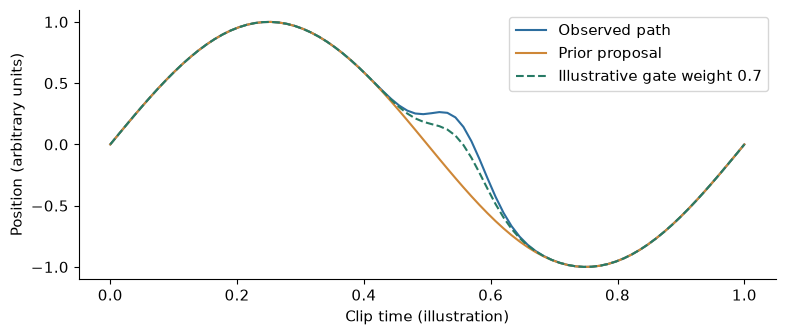

In [2]:
# This plot explains the gate, not learned behavior.
t = np.linspace(0, 1, 80)
prior_curve = np.sin(2 * np.pi * t)
observed_curve = prior_curve + 0.5 * np.exp(-((t - 0.55) / 0.06) ** 2)
fig, ax = plt.subplots()
ax.plot(t, observed_curve, label="Observed path", color="#2c6d9e")
ax.plot(t, prior_curve, label="Prior proposal", color="#ce8737")
ax.plot(t, prior_curve + .7 * (observed_curve - prior_curve),
        label="Illustrative gate weight 0.7", color="#277a65", linestyle="--")
ax.set(xlabel="Clip time (illustration)", ylabel="Position (arbitrary units)")
ax.legend(); plt.show()

## 2. Fit using train people only

Watch the optimization history for a stable fit. A lower training loss
is not the research outcome. The actual question is preservation at the
same repair quality on new people and a new event family.

The first pilot should use the small default model. Increase sample size
before adding architectural complexity. Compare the full evidence gate
with a direct coordinate model, simple flow checks and shuffled evidence.

In [3]:
started = perf_counter()
history = workflow.train_gate(cfg)
print(f"Training completed in {perf_counter() - started:.1f} seconds.")
display(history.tail(12))

Fitted gate_full_seed17: final loss=0.0916


Fitted gate_coordinates_seed17: final loss=0.0917


Fitted gate_shuffled_flow_seed17: final loss=0.0893


Fitted gate_random_features_seed17: final loss=0.1737


Training completed in 29.8 seconds.


,epoch,loss,restoration_loss,evidence_loss,seed,feature_mode
28,9,0.089566,0.022325,0.672415,17,shuffled_flow
29,10,0.089257,0.022206,0.670505,17,shuffled_flow
30,1,0.200573,0.130878,0.696958,17,random_features
31,2,0.197532,0.127924,0.696072,17,random_features
32,3,0.194278,0.124732,0.695459,17,random_features
33,4,0.191123,0.121594,0.695290,17,random_features
34,5,0.188043,0.118527,0.695157,17,random_features
35,6,0.184893,0.115394,0.694994,17,random_features
36,7,0.181930,0.112427,0.695029,17,random_features
37,8,0.179272,0.109787,0.694856,17,random_features


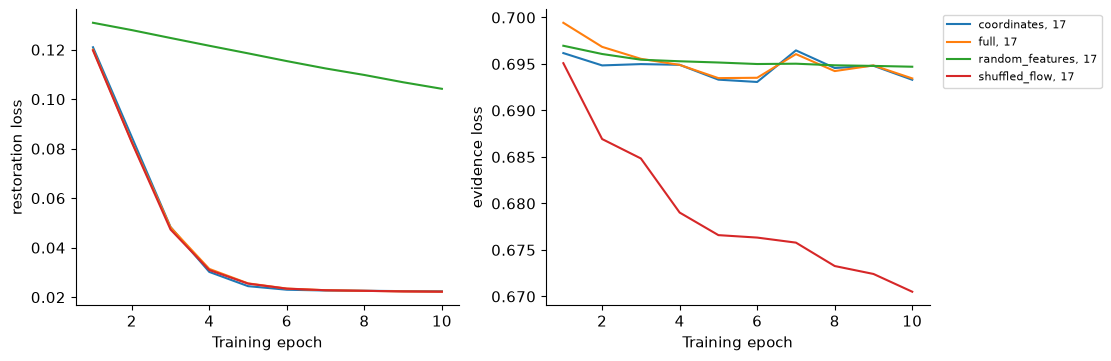

In [4]:
figure = plots.plot_history(history)
display(figure)
plt.close(figure)

## 3. Choose strength on calibration people, then lock it

A stronger repair may remove more noise and more true movement. For each
method, choose the operating strength on calibration people to approach
the same target noise removal. Lock that choice before looking at
development or final results.

Calibrate the event-evidence probability and an abstention threshold on
these same separate calibration observations. Report both probability
errors and the fraction of cases receiving a decision. Synthetic
calibration does not guarantee calibrated probabilities on GAVD.

In [5]:
operating_points = workflow.calibrate(cfg)
display(operating_points)
print("These operating points are selected using calibration data, not test retention.")

,method,strength,calibration_noise_removal,calibration_retention,feasible
0,raw,1.00,0.000000,0.906262,False
1,projected_raw,0.75,-0.800020,0.859340,False
2,prior,0.00,-0.800021,0.859340,False
3,conversion_only,0.00,-0.800021,0.859340,False
4,prior_unprojected,1.00,-532.647414,0.282328,False
5,conversion_only_unprojected,1.00,-1.383451,0.845728,False
6,gaussian,0.00,-0.800021,0.859340,False
7,median,0.00,-0.800021,0.859340,False
8,kalman,0.00,-0.800021,0.859340,False
9,confidence_gate,0.00,-0.800021,0.859340,False


These operating points are selected using calibration data, not test retention.


## 4. Keep the fitted model fixed

The next notebook evaluates the saved model, normalization and strengths.
It does not refit them. A full prespecified strength curve is useful for
understanding the tradeoff, but its best test point cannot replace the
locked primary comparison.

To fit three optimization seeds in one run, set `MP_SEEDS=17,23,42`
before training. The workflow reuses the same people and variants and
reports seed consistency. Use a new run directory when changing the
method or data condition. The bootstrap groups by person; frames,
variants and optimization seeds are not independent people.

Next: [04 · Measure preservation and repair](04_preservation_and_repair.ipynb).